Here I want to use the pricing models and try to test them over real world data.

Divergences between the theoretichal model and the real world price could be used to trade given a higher/lower market price respect to the predicted one.

In [43]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import tqdm
from datetime import datetime

tickers = ['NVDA', 'GOOGL', 'AAPL', 'GOOG', 'MSFT', 'AMZN', 'TSM', 'AVGO', 'META', 'TSLA', 'SMCI']

forex_tickers = [
    "EURUSD=X",
    "GBPUSD=X",
    "USDJPY=X",
    "USDCHF=X",
    "AUDUSD=X",
    "USDCAD=X",
    "NZDUSD=X",
    "EURGBP=X",
    "EURJPY=X",
    "GBPJPY=X",
    "EURCHF=X"
]

# for log and output save
now = datetime.now()
date = now.strftime("%Y-%m-%d %H:%M:%S")

In [53]:
def load_stock(start_date, stock='NVDA'):
    df = yf.download(stock, start=start_date, end=datetime.today(), interval='1d')

    if isinstance(df.columns, pd.MultiIndex):
        lvl0 = df.columns.get_level_values(0)
        lvl1 = df.columns.get_level_values(1)

        if 'Close' in lvl0:
            df.columns = lvl0
        elif 'Close' in lvl1:
            df.columns = lvl1

    df = df.loc[:, ~df.columns.duplicated()].copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['Close']).copy()
    return df

In [ ]:
def black_scholes_call(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

def black_scholes_put(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return put_price

[*********************100%***********************]  1 of 1 completed


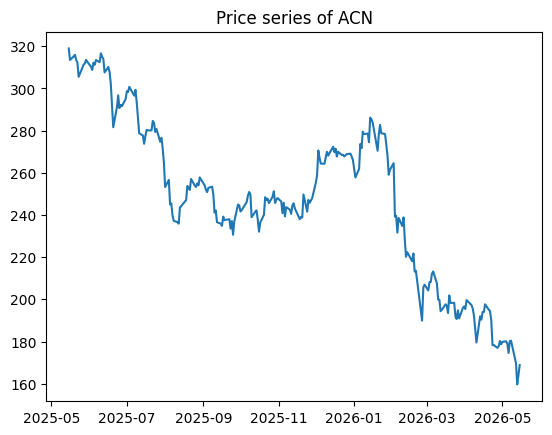

Selected European Options expiration:  2026-06-05


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
2,ACN260605C00155000,2026-05-14 14:52:26+00:00,155.0,13.0,14.0,17.3,0.0,0.0,NaN,6,0.56226,True,REGULAR,USD


In [63]:
# here i will import the data for creating the time series
stock = 'ACN'
data = load_stock(start_date='2025-05-15', stock=stock)

plt.plot(data['Close'])
plt.title(f'Price series of {stock}')
plt.show()

# retrieve the open options
ticker = yf.Ticker("ACN")

expiration = ticker.options[2]
print("Selected European Options expiration: ",expiration)

chain = ticker.option_chain(expiration)

calls = chain.calls
puts = chain.puts

calls.loc[calls['strike'] == 155]

In [68]:
# define the data historical volatility that is one of the parameters necessy for the theoretichal model.

returns = data['Close'].pct_change(1)

S0 = data['Close'][-1]

K = 155

today = datetime.today()
expiration_str = datetime.strptime(expiration, "%Y-%m-%d")
days = (expiration_str-today).days
T = days/365

r = 0.03 # impling a fixed riskfree rate

sigma = returns.std() # daily volatility
sigma *= np.sqrt(252) # annualized volatility

/var/folders/n8/1ntg40wj6dz8dn_j4bgmp7pc0000gn/T/ipykernel_22199/3607813791.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S0 = data['Close'][-1]


In [70]:
# baseline theoretical European options value with BS

call_price_BS = black_scholes_call(S0,K,T,r,sigma)
call_price_market = calls.loc[calls['strike'] == K, 'lastPrice'].iloc[0]

print(f"S0: {round(S0,2)}, Strike: {round(K,2)}, BS price: {round(call_price_BS,2)}, Market price: {call_price_market}")
print(f"Abs difference: {abs(round(call_price_BS-call_price_market,2))}")
print(f"Historical volatility: {round(sigma,2)}, Implied volatility: {round(calls.loc[calls['strike'] == K, 'impliedVolatility'].iloc[0],2)}")

S0: 168.82, Strike: 155, BS price: 14.91, Market price: 13.0
Abs difference: 1.91
Historical volatility: 0.34, Implied volatility: 0.56
